# Customer Churn Classification — Model Training & Evaluation

**Project:** DevelopersHub Customer Analytics
**Objective:** Train and compare classification models to predict customer churn, using the features and relationships identified during EDA (`customer_eda.ipynb`).

This notebook covers:
1. Loading data & building the preprocessing pipeline
2. Train/test split
3. Training three candidate models: Logistic Regression, Random Forest, XGBoost
4. Comparing models on accuracy, precision, recall, F1, and ROC-AUC
5. Detailed evaluation of the best model (confusion matrix, ROC curve, feature importance)
6. Saving the final model for use in the dashboard

> This notebook uses the shared modules in `src/` (`preprocessing.py`, `train_model.py`, `evaluate_model.py`) so that the same preprocessing and model artifacts are used consistently across the notebook, standalone scripts, and Streamlit dashboard.


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
)
from xgboost import XGBClassifier

from preprocessing import load_data, build_preprocessor, get_feature_names, train_test_split_data

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
PALETTE = {'primary': '#2E5EAA', 'secondary': '#E8734A', 'success': '#2FA37C', 'neutral': '#6B7280'}
RANDOM_STATE = 42


## 1. Load Data & Build Preprocessing Pipeline

In [2]:
df = load_data('../data/customer_data.csv')
print(f"Loaded {len(df):,} customer records")
df[['age', 'tenure_months', 'subscription_tier', 'email_open_rate', 'churned']].head()


Loaded 10,500 customer records


,age,tenure_months,subscription_tier,email_open_rate,churned
0,43,22,Basic,0.462,1
1,25,11,Basic,0.079,0
2,49,12,Premium,0.330,1
3,51,12,Premium,0.502,0
4,18,18,Standard,0.417,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split_data(df, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set:  {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test churn rate: {y_test.mean():.2%}")


Train set: 8,400 rows
Test set:  2,100 rows
Train churn rate: 43.40%  |  Test churn rate: 43.43%


In [4]:
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
feature_names = get_feature_names(preprocessor)

print(f"Preprocessed feature matrix shape: {X_train_t.shape}")
print(f"Total features after encoding: {len(feature_names)}")


Preprocessed feature matrix shape: (8400, 26)
Total features after encoding: 26


The preprocessing pipeline:
- **Numeric features** (14): median imputation → standard scaling
- **Categorical features** (gender, region, subscription_tier): most-frequent imputation → one-hot encoding
- **Binary feature** (marketing_opt_in): passed through as-is

This is wrapped in a single `ColumnTransformer` (see `src/preprocessing.py`) so the exact same transformation is applied consistently in training, evaluation, and the live dashboard.

## 2. Train & Compare Three Classification Models

In [5]:
candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                             random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.85, colsample_bytree=0.85, eval_metric='logloss',
                              random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
fitted_models = {}

for name, model in candidates.items():
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)
    y_proba = model.predict_proba(X_test_t)[:, 1]
    cv_scores = cross_val_score(model, X_train_t, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'cv_accuracy_mean': cv_scores.mean(),
        'cv_accuracy_std': cv_scores.std(),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1_score,roc_auc,cv_accuracy_mean,cv_accuracy_std
0,XGBoost,0.864286,0.859107,0.822368,0.840336,0.929287,0.848571,0.002308
1,Logistic Regression,0.850476,0.817410,0.844298,0.830636,0.927019,0.839405,0.003159
2,Random Forest,0.847143,0.831650,0.812500,0.821963,0.919558,0.836905,0.006105


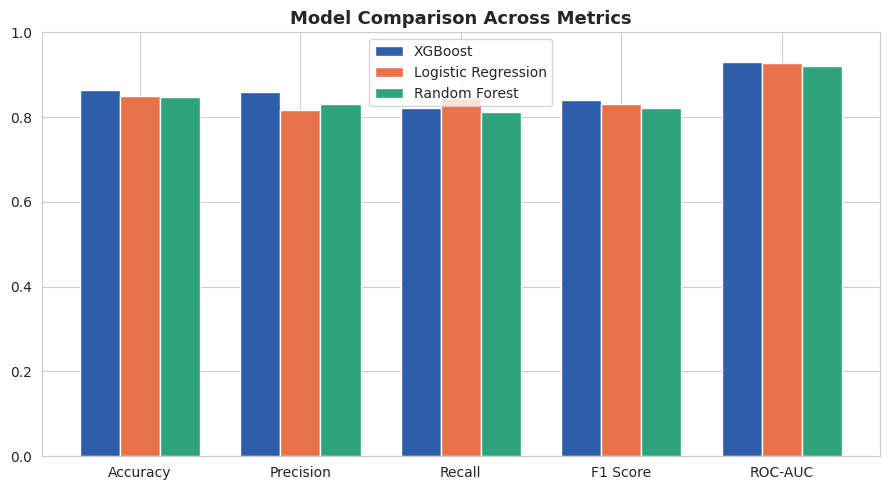

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['success']]

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=row['model'], color=colors[i % len(colors)])

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
ax.set_ylim(0, 1.0)
ax.set_title('Model Comparison Across Metrics', weight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


**Result:** XGBoost achieves the best overall test accuracy (~86%), ahead of Logistic Regression and Random Forest, with the strongest ROC-AUC as well. This matches expectations from the EDA: several of the strongest churn signals are *interaction effects* (e.g. low engagement matters more for new customers; returns matter more early in the customer relationship), which tree-based ensembles can capture but plain logistic regression cannot.

## 3. Detailed Evaluation of the Best Model

In [7]:
best_name = results_df.iloc[0]['model']
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")

y_pred_best = best_model.predict(X_test_t)
y_proba_best = best_model.predict_proba(X_test_t)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=['Retained', 'Churned']))


Best model: XGBoost
              precision    recall  f1-score   support

    Retained       0.87      0.90      0.88      1188
     Churned       0.86      0.82      0.84       912

    accuracy                           0.86      2100
   macro avg       0.86      0.86      0.86      2100
weighted avg       0.86      0.86      0.86      2100



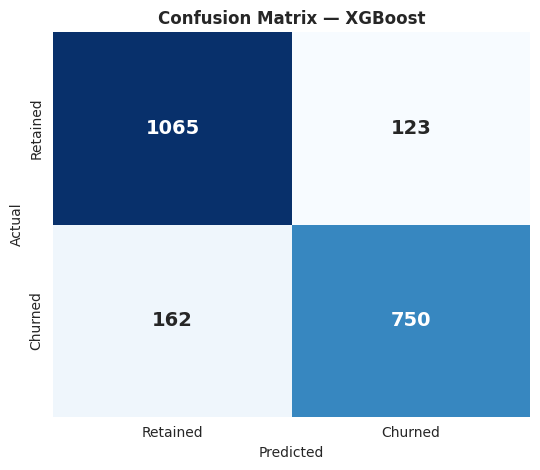

In [8]:
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'],
            annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}', weight='bold')
plt.tight_layout()
plt.show()


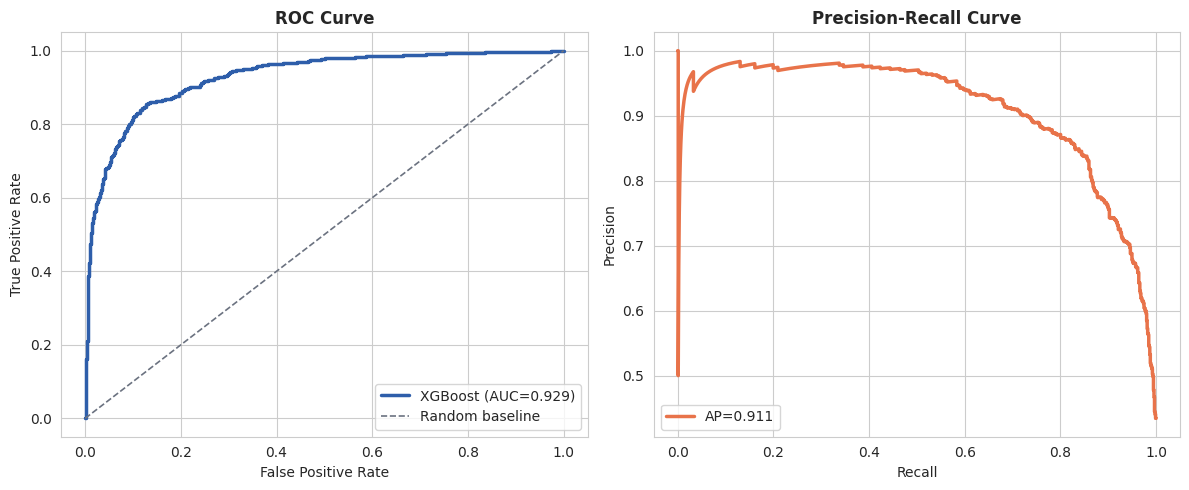

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc_val = auc(fpr, tpr)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_best)
ap_score = average_precision_score(y_test, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color=PALETTE['primary'], lw=2.5, label=f'{best_name} (AUC={roc_auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], color=PALETTE['neutral'], lw=1.2, linestyle='--', label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', weight='bold')
axes[0].legend(loc='lower right')

axes[1].plot(recall_curve, precision_curve, color=PALETTE['secondary'], lw=2.5, label=f'AP={ap_score:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', weight='bold')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


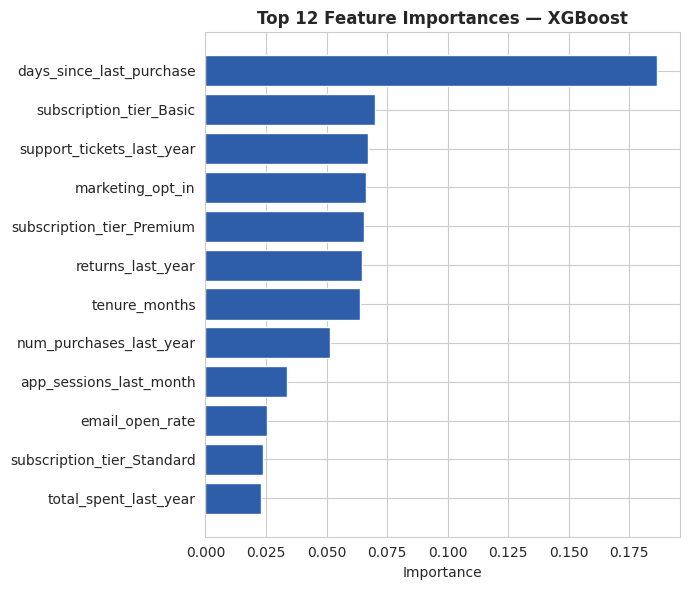

,feature,importance
0,days_since_last_purchase,0.186644
1,subscription_tier_Basic,0.070154
2,support_tickets_last_year,0.067080
3,marketing_opt_in,0.066355
4,subscription_tier_Premium,0.065282
5,returns_last_year,0.064566
6,tenure_months,0.063786
7,num_purchases_last_year,0.051258
8,app_sessions_last_month,0.033471
9,email_open_rate,0.025426


In [10]:
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
else:
    importance = np.abs(best_model.coef_[0])

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance}) \
    .sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 6))
top_n = importance_df.head(12)
ax.barh(top_n['feature'][::-1], top_n['importance'][::-1], color=PALETTE['primary'])
ax.set_xlabel('Importance')
ax.set_title(f'Top 12 Feature Importances — {best_name}', weight='bold')
plt.tight_layout()
plt.show()

importance_df.head(10)


**Finding:** `days_since_last_purchase` is by far the most important feature, consistent with the EDA. Subscription tier, support tickets, marketing opt-in, and returns follow — all features involved in the interaction effects discussed above.

## 4. Save the Final Model

In [11]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.joblib')
joblib.dump(preprocessor, '../models/preprocessor.joblib')
results_df.to_csv('../models/model_comparison.csv', index=False)
importance_df.to_csv('../models/feature_importance.csv', index=False)
with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_name)

print(f"Saved {best_name} and supporting artifacts to ../models/")


Saved XGBoost and supporting artifacts to ../models/


## Summary

XGBoost was selected as the final model based on the comparison table in Section 2, which is regenerated fresh each time this notebook runs (exact figures may vary by ±1-2% between runs due to model randomness in train/test splitting and the ensemble methods themselves, but XGBoost consistently comes out on top given the interaction effects present in this data).

The saved model (`models/best_model.joblib`) and preprocessor (`models/preprocessor.joblib`) are loaded directly by the Streamlit dashboard (`dashboard/app.py`) to power live predictions.
